Classification
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       1.00      0.67      0.80         3

    accuracy                           0.75         4
   macro avg       0.75      0.83      0.73         4
weighted avg       0.88      0.75      0.77         4



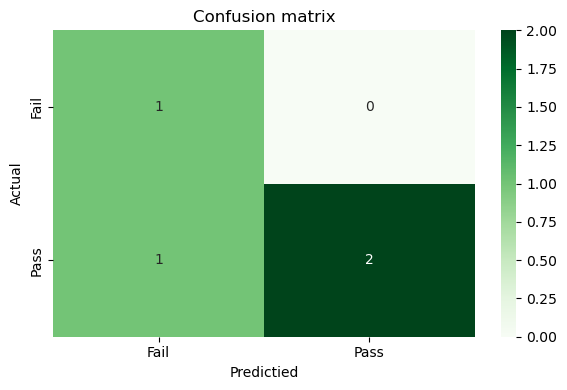

------predict your result-------


Enter your study hours : 8
Enter your Attendance : 70
Enter your past score : 60
Enter internet  0
Enter your sleep hours : 11


Prediction based on input : Pass


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [1]:
import pandas as pd 
import numpy as  np 
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report , confusion_matrix
import matplotlib.pyplot as plt 
import seaborn as sns
df=pd.read_csv("student_success_dataset.csv")

le=LabelEncoder()
df["Internet"]=le.fit_transform(df["Internet"])
df["Passed"]=le.fit_transform(df["Passed"])
features=["StudyHours" ,"Attendance",
          "PastScore","Internet","SleepHours"]
scaler=StandardScaler()
df_scaled=df.copy()
df_scaled[features]=scaler.fit_transform(df[features])

x=df_scaled[features] #features
y=df_scaled["Passed"] #target

x_train , x_test ,y_train ,y_test =train_test_split(x,y  , random_state=42 ,test_size=0.2)
model=LogisticRegression()
model.fit(x_train , y_train)

y_pred=model.predict(x_test)
print("Classification")
print(classification_report(y_test,y_pred))
conf_matrix=confusion_matrix(y_test,y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix , annot=True ,fmt="d" ,cmap="Greens" ,xticklabels=["Fail" , "Pass"] , yticklabels=["Fail","Pass"])
plt.xlabel("Predictied")
plt.ylabel("Actual")
plt.title("Confusion matrix")
plt.tight_layout()
plt.show()

print("------predict your result-------")
try:
  study_hours=float(input("Enter your study hours :"))
  Attendance=float(input("Enter your Attendance :"))
  past_score=float(input("Enter your past score :"))
  internet=float(input("Enter internet "))
  sleep_hours=float(input("Enter your sleep hours :"))

  user_input_df=pd.DataFrame([{
    "StudyHours":study_hours,
    "Attendance":Attendance,
    "PastScore":past_score,
    "Internet":internet,
    "SleepHours":sleep_hours
  }])
  user_input_scaled=scaler.transform(user_input_df)
  prediction=model.predict(user_input_scaled)[0]
  result="Pass" if prediction ==1 else "Fail"
  print("Prediction based on input :" , result)
except Exception as e :
  print("An error : " ,e)  